In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_cleaned_v2.csv")

In [5]:
df.head(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,...,NaN,750.0,NaN,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,NaN,1449.0,NaN,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,1950.0,Carpet area: 1950 (181.16 sq.m.),4,5,3,...,NaN,NaN,1950.00,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,...,1650.0,NaN,1022.58,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,...,1370.0,NaN,NaN,0,0,0,0,0,1,49


In [6]:
df.shape

(3801, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3801 entries, 0 to 3800
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_type          3801 non-null   object 
 1   society                3800 non-null   object 
 2   sector                 3801 non-null   object 
 3   price                  3784 non-null   float64
 4   price_per_square_feet  3784 non-null   float64
 5   area                   3784 non-null   float64
 6   areaWithType           3801 non-null   object 
 7   bedRoom                3801 non-null   int64  
 8   bathroom               3801 non-null   int64  
 9   balcony                3801 non-null   object 
 10  floorNum               3782 non-null   float64
 11  facing                 2697 non-null   object 
 12  agePossession          3801 non-null   object 
 13  super_built_up_area    1914 non-null   float64
 14  built_up_area          1733 non-null   float64
 15  carp

In [8]:
df.duplicated().sum()

np.int64(126)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

# Property Type 

In [11]:
df['property_type'].value_counts()

property_type
flat     2816
house     859
Name: count, dtype: int64

<Axes: xlabel='property_type', ylabel='count'>

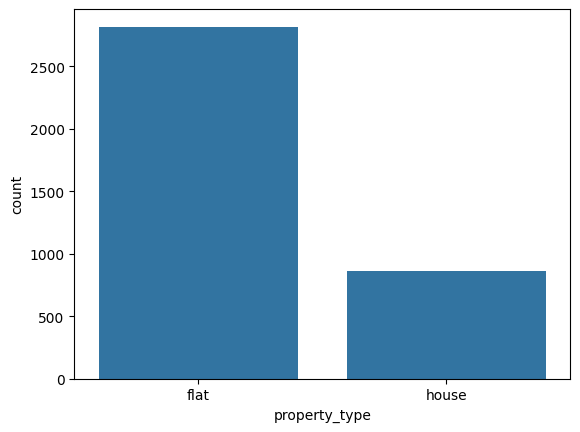

In [12]:
sns.countplot(data=df, x='property_type')

In [24]:
pct_flat = (df[df['property_type'] == "flat"].shape[0]/df['property_type'].shape[0])*100
pct_house = (df[df['property_type'] == "house"].shape[0]/df['property_type'].shape[0])*100

**Observations :** 

**1. We have 76% data of Flat and 24% data of house in our entire dataset.**

**2. There are no Missing Values.**

# Society 

In [25]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
ashok vihar phase iii extension           1
jmd gardens                               1
the castle society                        1
millenium bajrang society                 1
ashiana apartment                         1
Name: count, Length: 674, dtype: int64

In [44]:
df['society'].value_counts().shape

(674,)

In [26]:
df['society'].isnull().sum()

np.int64(1)

In [33]:
df['society'].value_counts().sort_values(ascending=False).head(10)

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
signature global park                    35
shree vardhman victoria                  34
smart world orchard                      32
emaar mgf emerald floors premier         32
dlf the ultima                           31
Name: count, dtype: int64

In [ ]:
df[df['society'] == "independent"].shape[0] / df['society'].shape[0] * 100

13.224489795918368

<Axes: xlabel='society'>

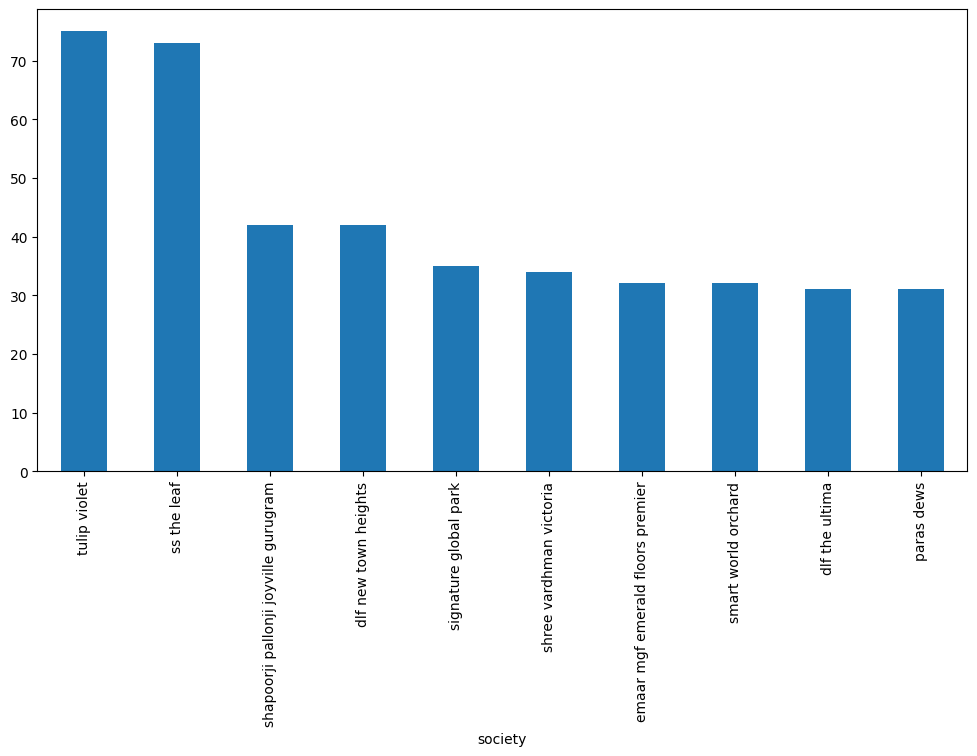

In [41]:
df[df['society'] != "independent"]['society'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))

In [42]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023526
ss the leaf                             0.046424
shapoorji pallonji joyville gurugram    0.059598
dlf new town heights                    0.072773
signature global park                   0.083752
                                          ...   
puri emerald bay                        0.490590
umang monsoon breeze                    0.494668
indiabulls enigma                       0.498745
central park flower valley              0.502509
ireo the corridors                      0.506274
Name: proportion, Length: 75, dtype: float64

In [45]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(306)}

**Observations :**

**1. Around 13% properties comes under independent tag.**

**2. There are 673 societies.**

**3. The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 598 societies**

**4. Very High (>100): Only 1 society has more than 100 listings.**

**5. High (50-100): 2 societies have between 50 to 100 listings.**

**6. Average (10-49): 92 societies fall in this range with 10 to 49 listings each.**

**7. Low (2-9): 273 societies have between 2 to 9 listings.**

**8. Very Low (1): A significant number, 308 societies, have only 1 listing.**

**9. 1 missing value**

# Sector

In [46]:
df['sector'].value_counts()

sector
sohna road    154
sector 85     108
sector 102    107
sector 92     100
sector 69      93
             ... 
sector 17a      3
sector 27       3
sector 17b      3
sector 73       3
sector 88b      3
Name: count, Length: 112, dtype: int64

In [47]:
df['sector'].value_counts().shape

(112,)

In [48]:
df['sector'].isnull().sum()

np.int64(0)

In [51]:
df['sector'].unique()

array(['sector 102', 'sector 56', 'sector 48', 'sector 92', 'sector 104',
       'sector 108', 'sector 6', 'sector 70', 'sector 113', 'sector 103',
       'sector 26', 'sector 54', 'manesar', 'sector 23', 'sector 49',
       'sector 99', 'sector 28', 'sector 37c', 'sector 70a', 'sector 57',
       'sector 2', 'sector 59', 'sector 12', 'sector 79', 'sohna road',
       'sector 83', 'sector 69', 'sector 62', 'sector 52', 'sector 3',
       'sector 33', 'sector 38', 'sector 85', 'sector 111', 'sector 84',
       'sector 41', 'sector 107', 'sector 65', 'sector 36', 'sector 50',
       'sector 90', 'sector 7', 'sector 77', 'sector 82', 'sector 71',
       'sector 67', 'sector 43', 'sector 4', 'sector 37d', 'sector 31',
       'sector 46', 'sector 99a', 'sector 68', 'sector 81', 'sector 51',
       'sector 66', 'sector 109', 'sector 61', 'sector 45', 'sector 63',
       'sector 86', 'sector 76', 'sector 60', 'sector 89', 'sector 1',
       'sector 58', 'sector 110', 'sector 91', 'sector 72',

<Axes: xlabel='sector'>

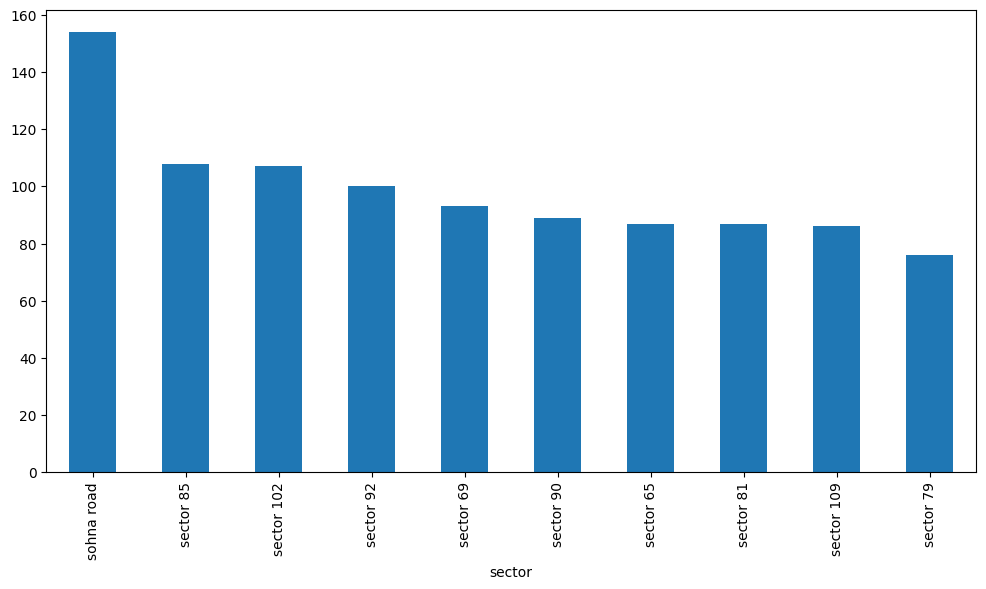

In [52]:
df['sector'].value_counts().head(10).plot(kind='bar', figsize=(12,6))

In [53]:
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(22),
 'Very Low (1)': np.int64(0)}

**Observations :** 

**There are a total of 104 unique sectors in the dataset.**

**Frequency distribution of sectors:**

**1.Very High (>100): 3 sectors have more than 100 listings.**

**2.High (50-100): 25 sectors have between 50 to 100 listings.**

**3.Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.**

**4.Low (2-9): 16 sectors have between 2 to 9 listings.**

**5.Very Low (1): Interestingly, there is only 1 sector with only 1 listing.**

# Price (Most Imp)

In [56]:
df['price'].isnull().sum()

np.int64(16)

In [57]:
df['price'].describe()

count    3659.000000
mean        2.534173
std         2.980872
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

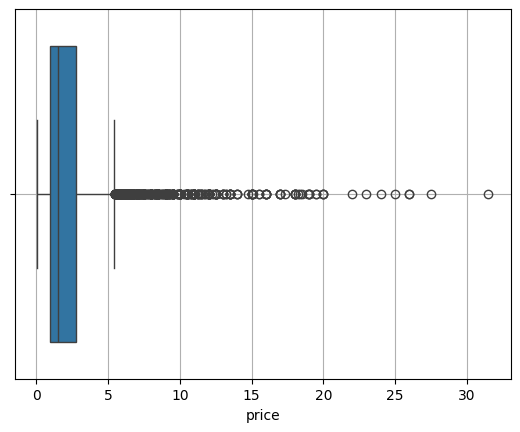

In [61]:
sns.boxplot(x = df['price'])
plt.grid()

<Axes: xlabel='price', ylabel='Count'>

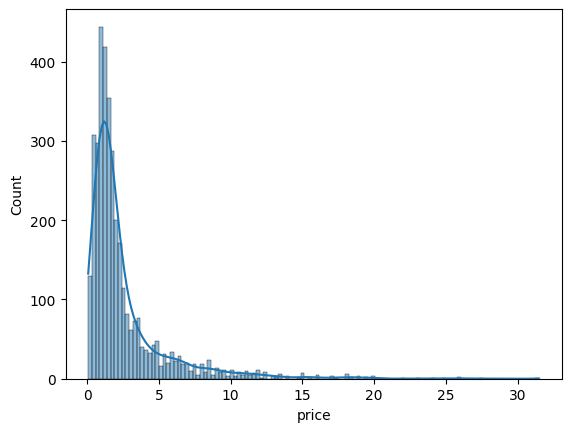

In [63]:
sns.histplot(df['price'],kde=True)

In [66]:
skewness = df['price'].skew()

In [67]:
kurtosis = df['price'].kurtosis()

In [68]:
print(skewness,kurtosis)

3.278802486806282 14.930026075602346


Skewness > 0 -> It indicates that we have a right skewed data.

Kurtosis > 3 -> Leptokurtic , Meaning we have huge amount of outliers/ heavy tail

In [70]:
df['price'].quantile([0.01, 0.05,0.5, 0.95, 0.99])

0.01     0.250
0.05     0.370
0.50     1.520
0.95     8.500
0.99    15.268
Name: price, dtype: float64

Quantile Analysis:

1% Quantile: Only 1% of properties are priced below 0.25 crores.

5% Quantile: 5% of properties are priced below 0.37 crores.

50% Quantile : 50% of Properties are priced below 1.5 crores

95% Quantile: 95% of properties are priced below 8.5 crores.

99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [71]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [72]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [75]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [76]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

Based on the IQR method, there are 425 properties considered as outliers.

These outliers have an average price of approximately 9.24 crores.

The range for these outliers is from 5.46 crores to 31.5 crores.

In [77]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]

<Axes: xlabel='price'>

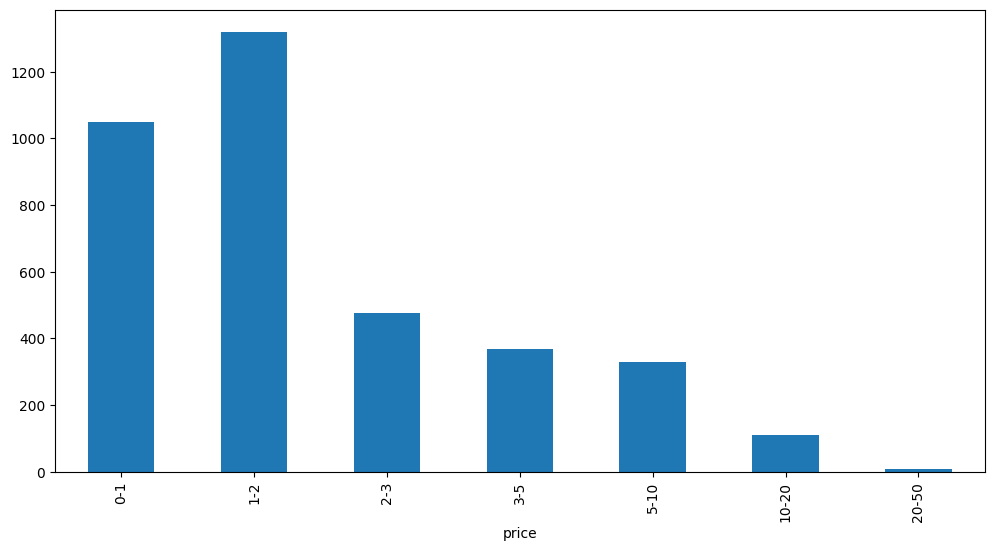

In [84]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'] , bins=bins, labels=bin_labels).value_counts().sort_index().plot(kind='bar', figsize=(12,6))

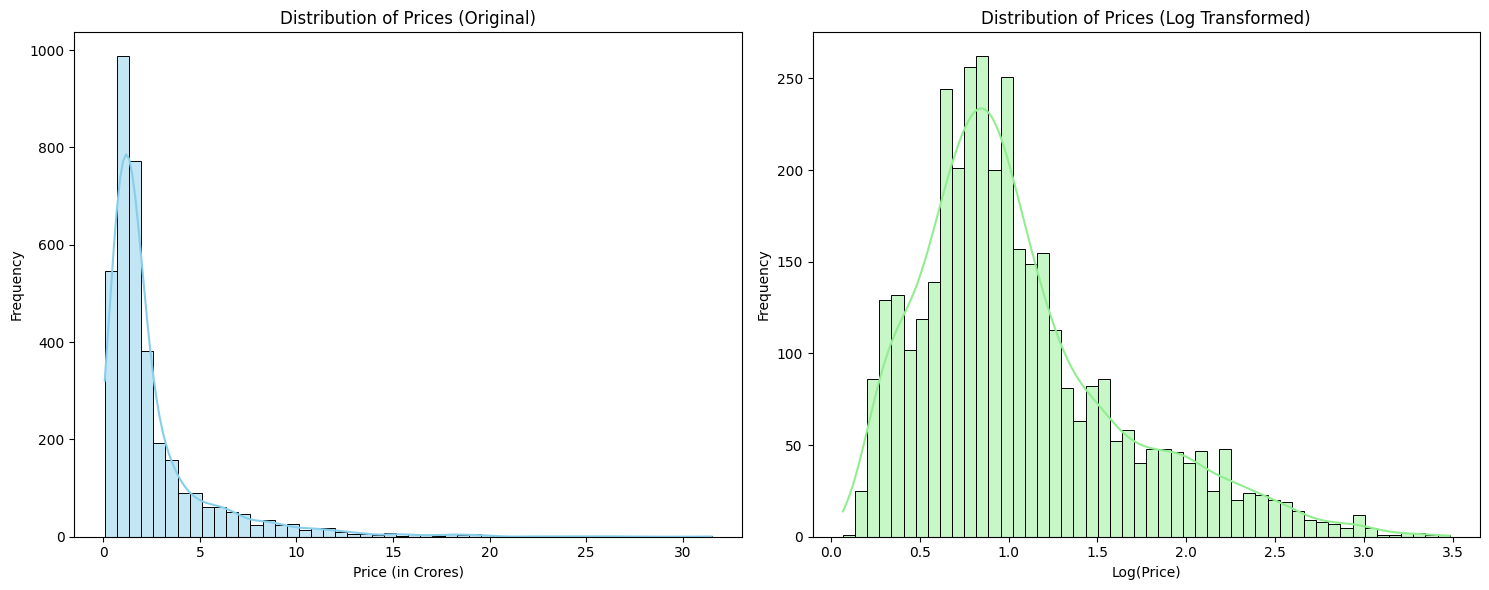

In [93]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [86]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.073773240858011 0.9641938373680206


Text(0, 0.5, 'Frequency')

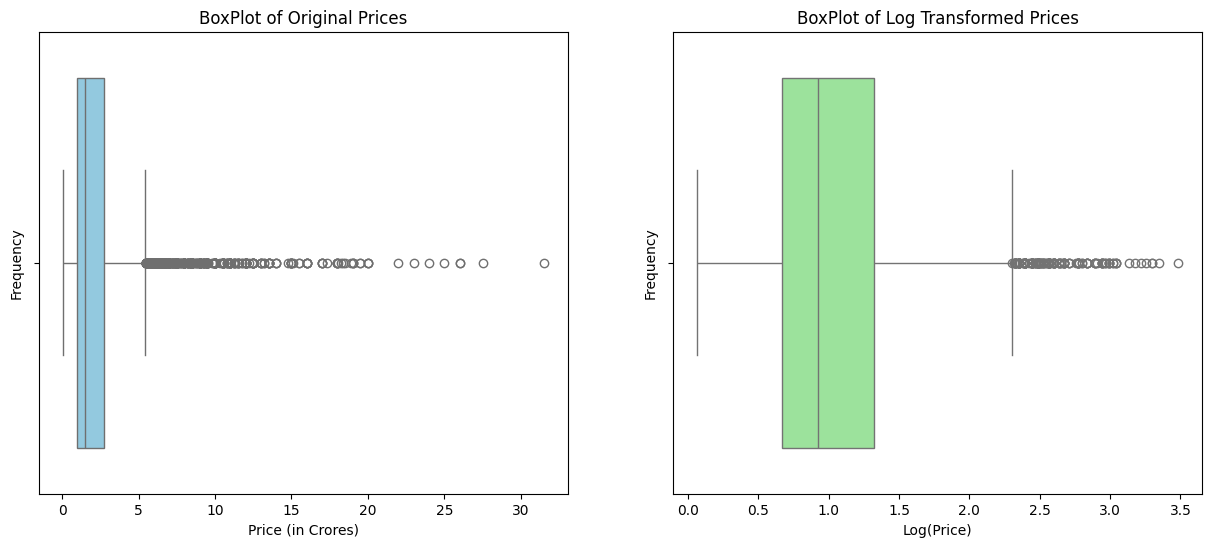

In [104]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x = df['price'] , color='skyblue')
plt.title('BoxPlot of Original Prices')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.boxplot(x = np.log1p(df['price']) , color='lightgreen')
plt.title('BoxPlot of Log Transformed Prices')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

# Price Per Sq Feet

In [105]:
df['price_per_square_feet'].isnull().sum()

np.int64(16)

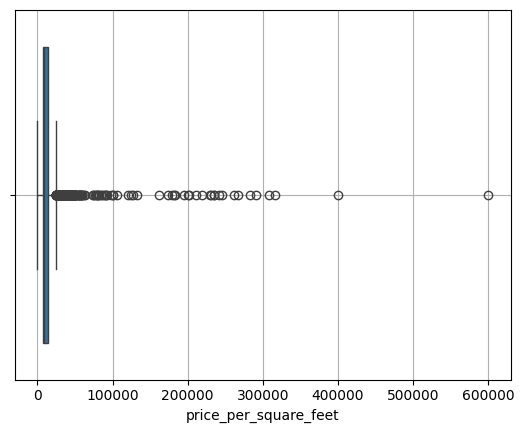

In [107]:
sns.boxplot(x = df['price_per_square_feet'])
plt.grid()

<Axes: xlabel='price', ylabel='Count'>

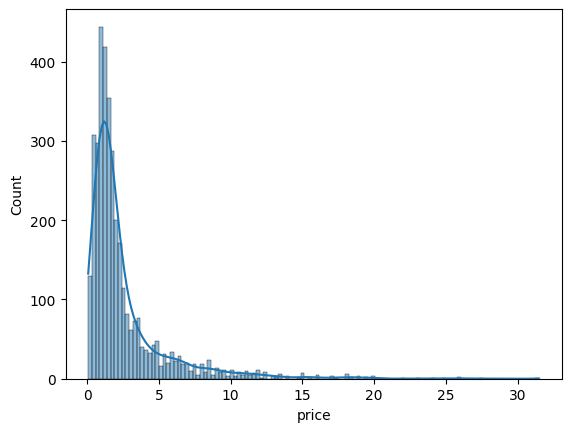

In [108]:
sns.histplot(df['price'],kde=True)

In [109]:
df['price_per_square_feet'].describe()

count      3659.000000
mean      13894.939328
std       23212.832775
min           4.000000
25%        6818.000000
50%        9020.000000
75%       13883.000000
max      600000.000000
Name: price_per_square_feet, dtype: float64

In [110]:
df['price_per_square_feet'].skew()

np.float64(11.435949118649672)

In [111]:
df['price_per_square_feet'].kurtosis()

np.float64(186.88501274405968)

Observations

Potential Outliers

Right Skewed

16 missing values

# bedRoom

In [113]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

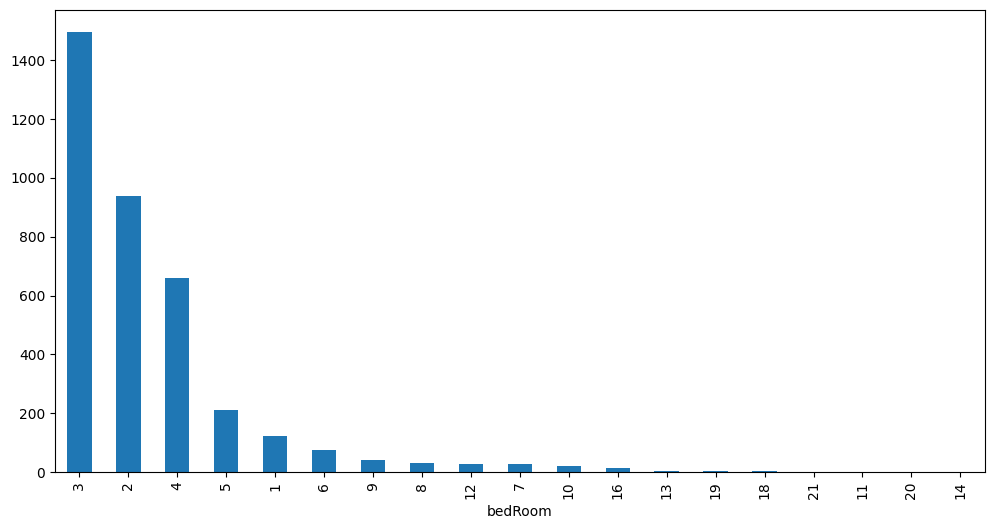

In [115]:
df['bedRoom'].value_counts().plot(kind='bar', figsize=(12,6))

<Axes: ylabel='count'>

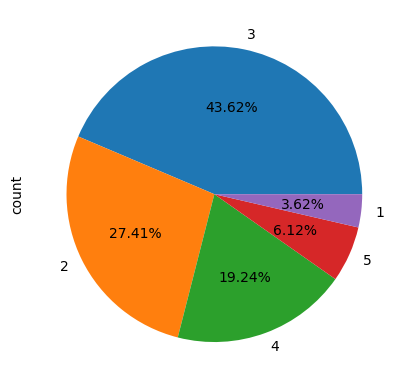

In [118]:
df['bedRoom'].value_counts().head().plot(kind = 'pie',autopct = '%0.2f%%')

# bathRoom

In [119]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

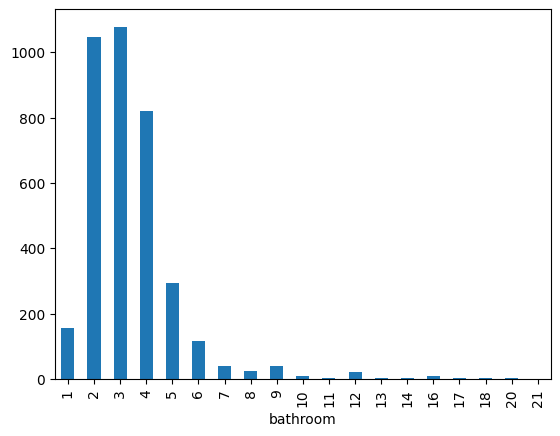

In [120]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

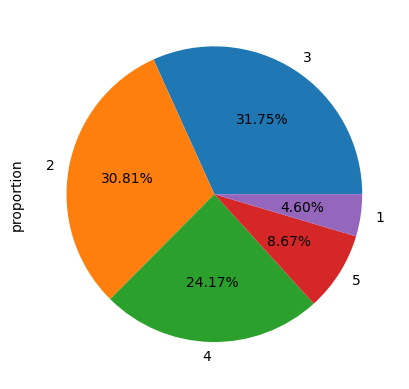

In [121]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# balcony

In [122]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

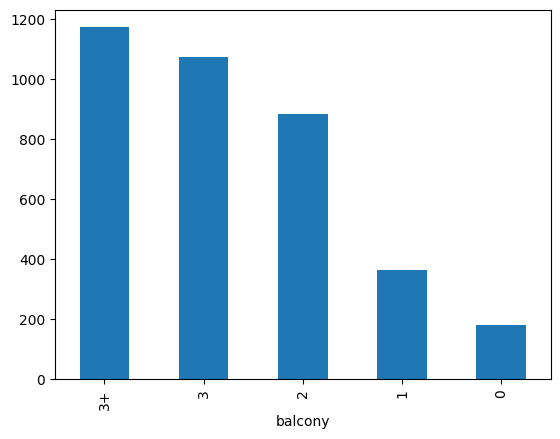

In [123]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

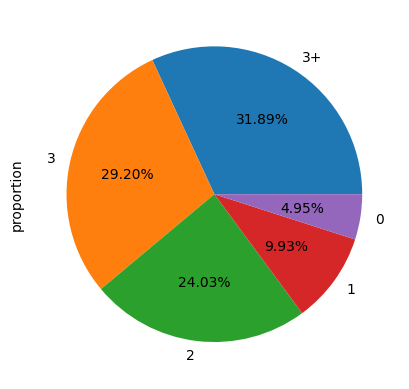

In [124]:

df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# Floor Num

In [125]:
df['floorNum'].isnull().sum()

np.int64(19)

In [126]:
df['floorNum'].value_counts()

floorNum
3.0     497
2.0     493
1.0     351
4.0     316
8.0     195
6.0     183
10.0    179
7.0     176
5.0     169
9.0     161
12.0    158
0.0     129
11.0    112
14.0    112
15.0     80
16.0     52
17.0     46
13.0     42
18.0     36
19.0     33
20.0     26
21.0     16
23.0     14
22.0     13
24.0     11
25.0      9
27.0      8
26.0      5
30.0      5
33.0      4
28.0      4
31.0      3
29.0      3
34.0      2
43.0      2
35.0      2
39.0      2
32.0      2
40.0      1
44.0      1
51.0      1
45.0      1
38.0      1
Name: count, dtype: int64

<Axes: xlabel='floorNum', ylabel='Count'>

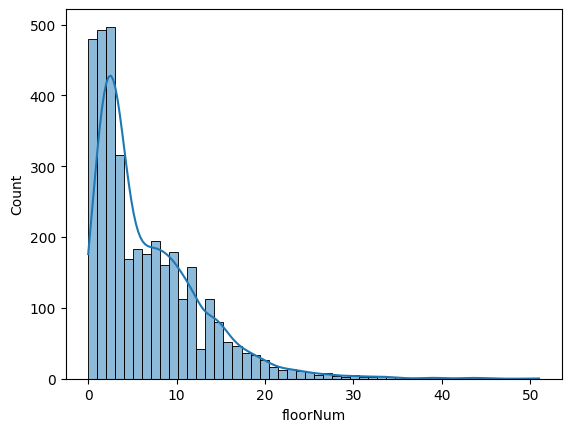

In [130]:
sns.histplot(df['floorNum'], kde=True)

<Axes: xlabel='floorNum'>

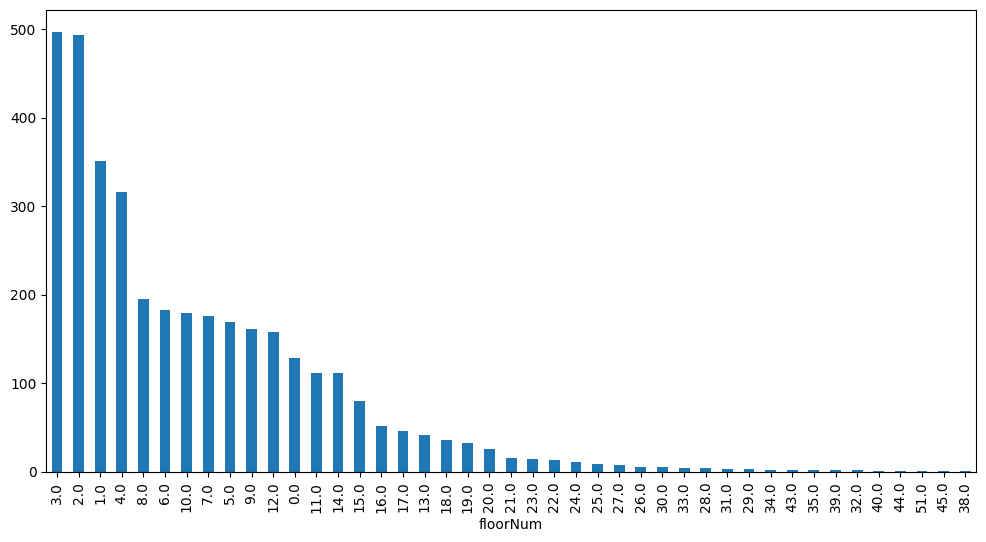

In [127]:
df['floorNum'].value_counts().plot(kind='bar', figsize=(12,6))

In [128]:
df['floorNum'].describe()

count    3656.000000
mean        6.798140
std         6.013369
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

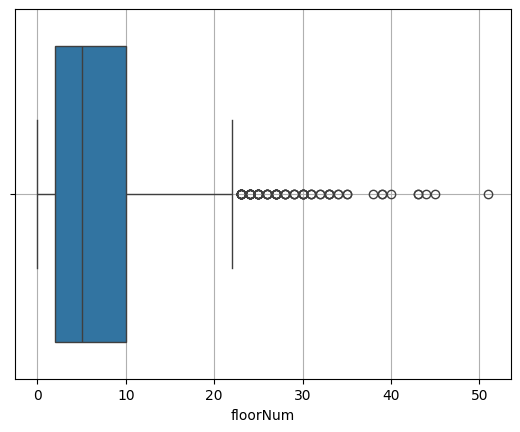

In [131]:
sns.boxplot(x = df['floorNum'])
plt.grid()

Observations : 

The majority of the properties lie between the ground floor (0) and the 25th floor.

Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.

There are a few properties located at higher floors, but their frequency is much lower.

The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.

Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

# Facing

In [132]:
df['facing'].isnull().sum()

np.int64(1044)

In [133]:
df['facing'].fillna('NA',inplace=True)

In [134]:
df['facing'].value_counts()

facing
NA            1044
North-East     623
East           622
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

# Age Possession

In [135]:
df['agePossession'].isnull().sum()

np.int64(0)

In [136]:
df['agePossession'].value_counts()

agePossession
Relatively New        1645
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     265
Name: count, dtype: int64

<Axes: xlabel='agePossession'>

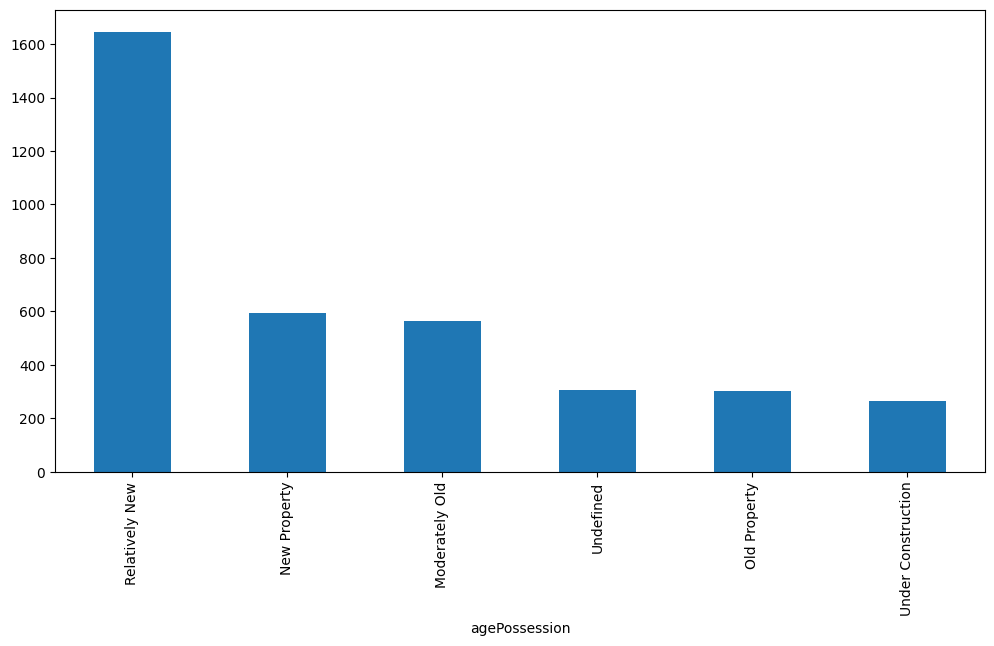

In [137]:
df['agePossession'].value_counts().plot(kind='bar', figsize=(12,6))

<Axes: ylabel='count'>

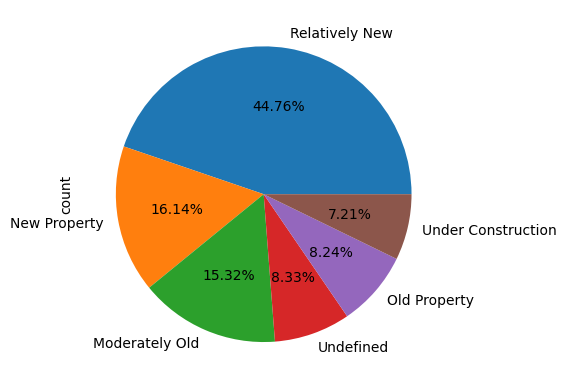

In [138]:
df['agePossession'].value_counts().plot(kind = "pie" , autopct='%0.2f%%')

# Areas 

1. Super Built Up Area 

2. Built Up Area

3. Carpet Area

1. Super Built Up Area

In [139]:
df['super_built_up_area'].isnull().sum()

np.int64(1801)

In [143]:
df[df['super_built_up_area'].isnull()][['area' , 'super_built_up_area', 'carpet_area', 'built_up_area']].sample(3)

,area,super_built_up_area,carpet_area,built_up_area
292,1125.0,NaN,NaN,1125.0
3674,2100.0,NaN,2100.0,NaN
3715,3950.0,NaN,2900.0,3950.0


In [144]:
df['super_built_up_area'].describe()

count     1874.000000
mean      1925.624626
std        764.192336
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

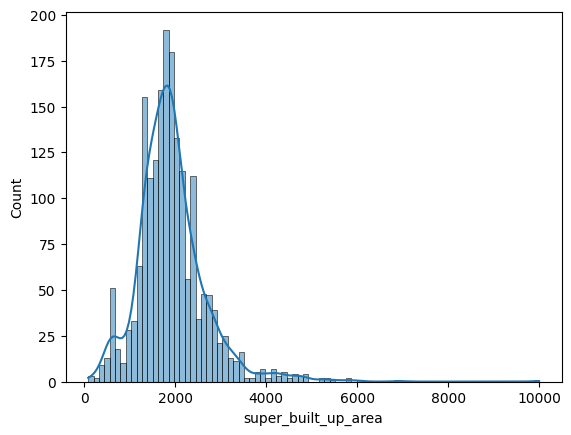

In [145]:
sns.histplot(df['super_built_up_area'],kde=True)  

<Axes: xlabel='super_built_up_area'>

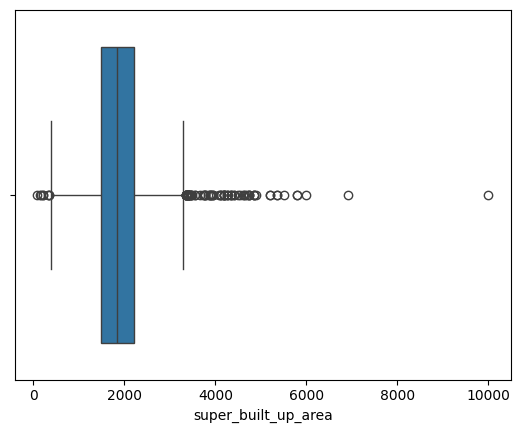

In [146]:
sns.boxplot(x = df['super_built_up_area'])

Observations : 

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.

There are a few properties with a significantly larger area, leading to a right-skewed distribution.

The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.

There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

2. Built Up Area 

In [147]:
df['built_up_area'].isnull().sum()

np.int64(1985)

In [148]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

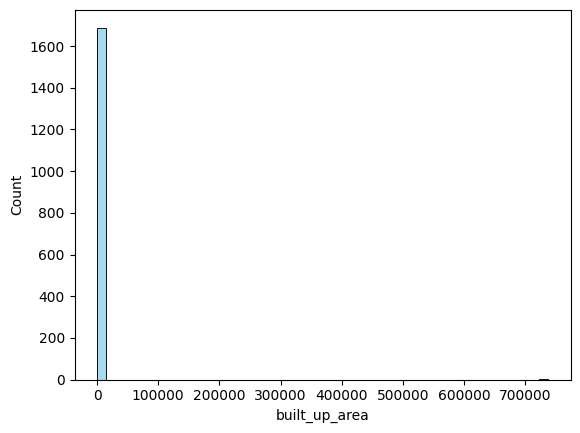

In [156]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

In [161]:
# Binning the values 
samples = df['built_up_area']

built_up_samples = {
    "Very High (>5000)": (samples > 5000.0).sum(),
    "High (1000-4999)": ((samples >= 1000.0) & (samples <= 4999.0)).sum(),
    "Average (500-1000)": ((samples >= 500.0) & (samples < 1000.0)).sum(),
    "Low (150-500)": ((samples >= 150.0) & (samples < 500.0)).sum(),
    "Very Low (0-150)": ((samples >= 0.0) & (samples < 150.0)).sum()
}

built_up_samples

{'Very High (>5000)': np.int64(68),
 'High (1000-4999)': np.int64(1243),
 'Average (500-1000)': np.int64(199),
 'Low (150-500)': np.int64(127),
 'Very Low (0-150)': np.int64(46)}

<Axes: xlabel='built_up_area'>

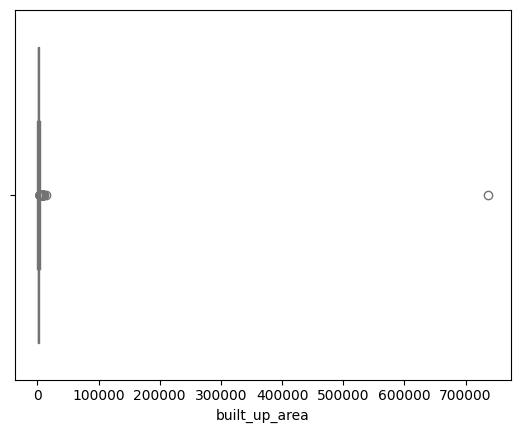

In [153]:
sns.boxplot(x = df['built_up_area'].dropna(), color='lightgreen')

Observations : 

Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.

There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.

The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors.
 
This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

3. Carpet Area

In [162]:
df['carpet_area'].isnull().sum()

np.int64(1804)

In [163]:
df['carpet_area'].describe()

count      1871.00000
mean       2530.22281
std       22805.88715
min          15.00000
25%         845.00000
50%        1300.00000
75%        1790.00000
max      607936.00000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

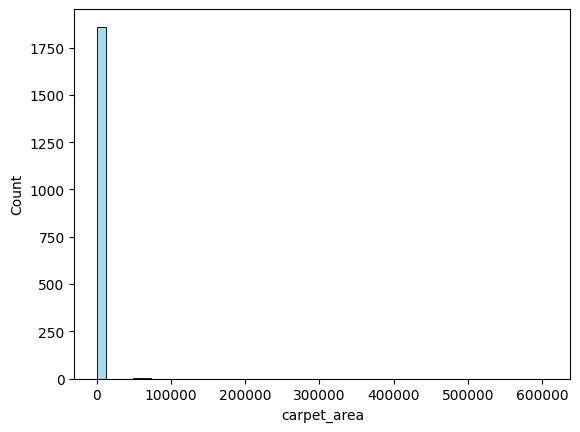

In [164]:

sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='carpet_area'>

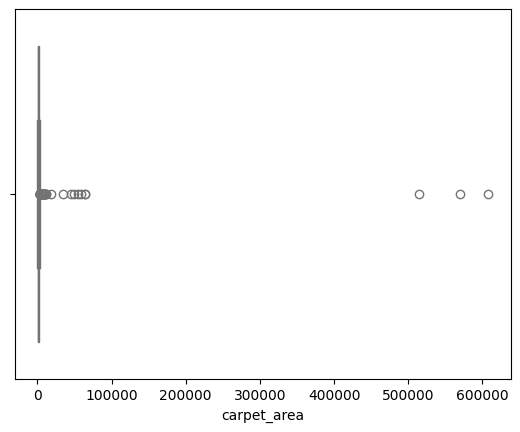

In [167]:
sns.boxplot(x = df['carpet_area'].dropna(), color='lightgreen')

# Additional Rooms

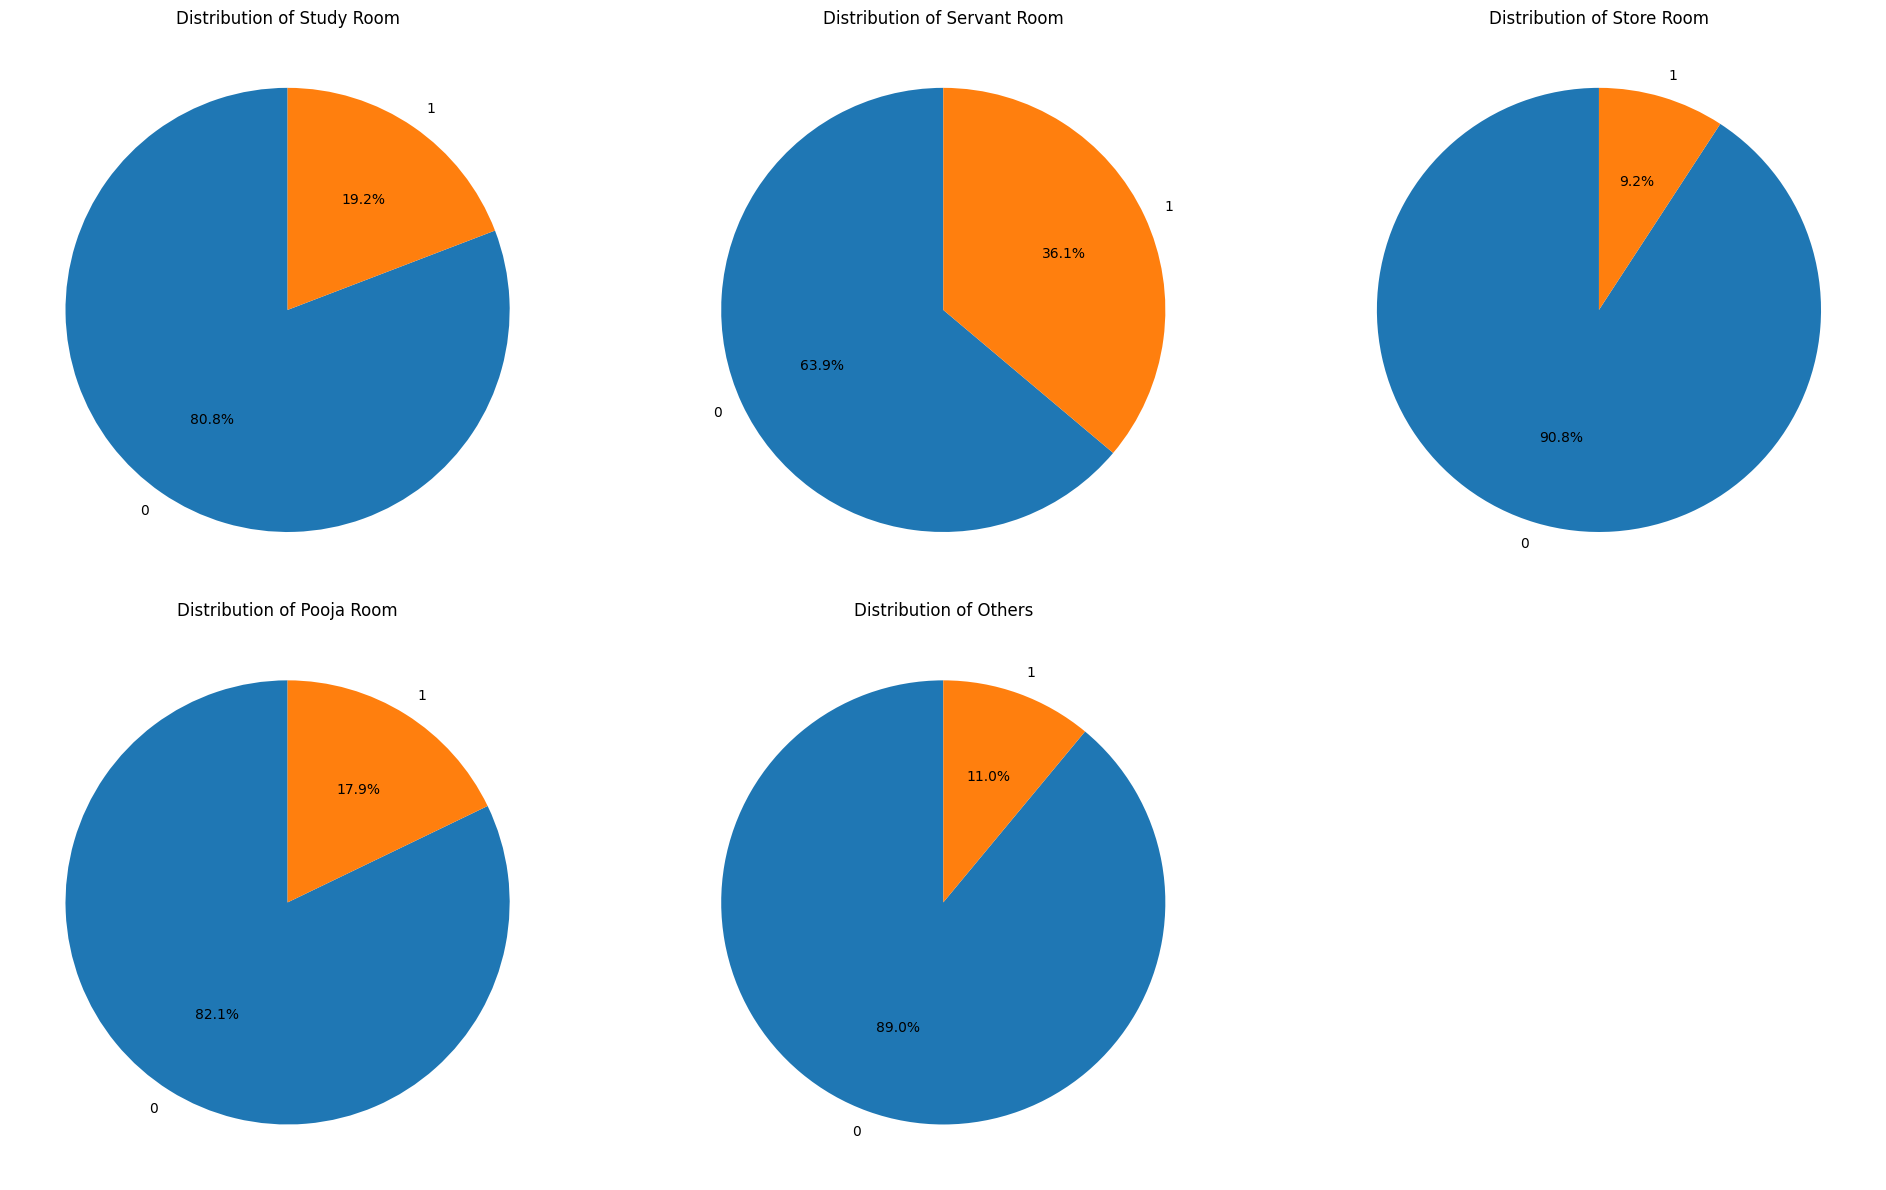

In [168]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Furnishing Type

In [169]:
df['furnishing_type'].value_counts()

furnishing_type
1    2434
0    1038
2     203
Name: count, dtype: int64

<Axes: ylabel='count'>

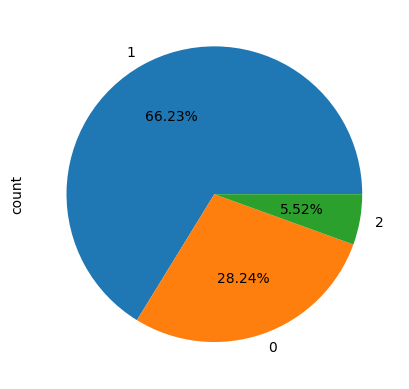

In [170]:

df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

# Luxury Score

In [171]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [172]:
df['luxury_score'].describe()

count    3675.000000
mean       71.517279
std        53.064780
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

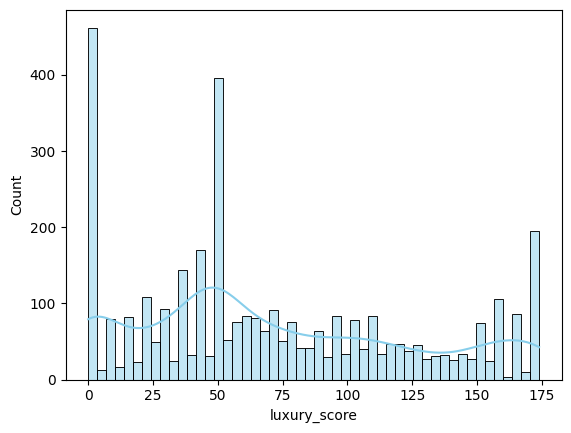

In [173]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

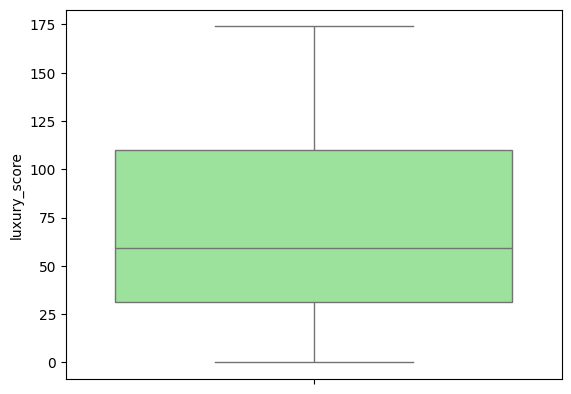

In [174]:

sns.boxplot(df['luxury_score'], color='lightgreen')

Observation 

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.